# Classification binaire : Gravite (Grave vs Non grave)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du jeu de données

In [2]:
df = pd.read_csv("data/processed/accidents_encoded_ready.csv")

In [3]:
# 1. Création de la cible binaire
df['grav_binaire'] = df['grav'].apply(lambda x: 1 if x in [3, 4] else 0)

grav_binaire
0    0.610302
1    0.389698
Name: proportion, dtype: float64


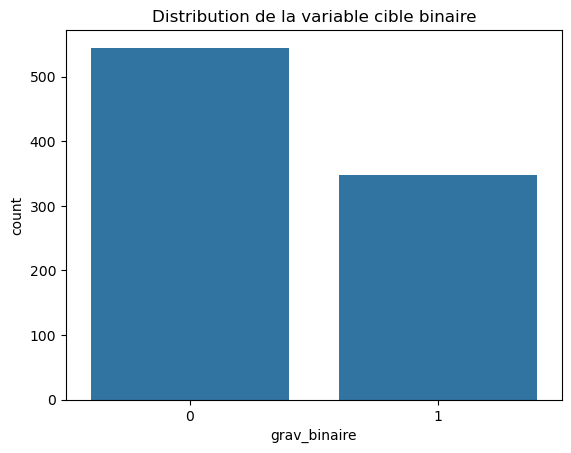

In [4]:
# 2. Vérification de la répartition
print(df['grav_binaire'].value_counts(normalize=True))
sns.countplot(x='grav_binaire', data=df)
plt.title("Distribution de la variable cible binaire")
plt.show()

#Déséquilibre important : la classe des accidents graves est nettement minoritaire.
#Cela peut biaiser l'entraînement (le modèle peut prédire uniquement la classe majoritaire).

In [5]:
# 3. Préparation des données
X = df.drop(columns=['grav', 'grav_binaire']) 
y = df['grav_binaire']

In [6]:
# Dummy encoding si besoin (ex : si variables catégorielles encore présentes)
X = pd.get_dummies(X, drop_first=True)

In [7]:
# 4. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [8]:
# 5. Entraînement Random Forest (baseline)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
# 6. Évaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\nClassification Report :\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix :\n", confusion_matrix(y_test, y_pred))
print("\nROC AUC :", roc_auc_score(y_test, y_proba))


Classification Report :
               precision    recall  f1-score   support

           0       0.77      0.85      0.81       109
           1       0.72      0.60      0.66        70

    accuracy                           0.75       179
   macro avg       0.75      0.73      0.73       179
weighted avg       0.75      0.75      0.75       179


Confusion Matrix :
 [[93 16]
 [28 42]]

ROC AUC : 0.7939711664482307


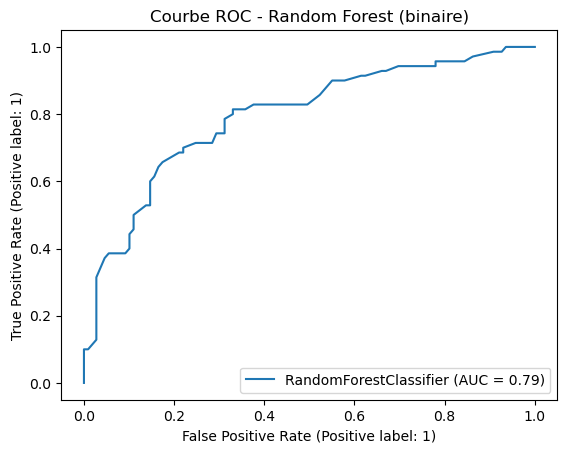

In [10]:
# Courbe ROC
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("Courbe ROC - Random Forest (binaire)")
plt.show()
#Objectif métier
#L'objectif n’est pas juste l’accuracy, mais repérer un maximum d'accidents graves (classe 1) → c’est un enjeu de sécurité.
#Le modèle binaire fonctionne globalement bien (AUC = 0.85) → il sait séparer les classes, c’est positif.
#Mais il est déséquilibré : il privilégie la classe 0 (accidents non graves).

In [11]:
#  Modèle de base : Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

C:\Users\fatis\anaconda3\envs\accidents\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [12]:
# Prédictions et probabilités
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("--- Logistic Regression ---")
print("Classification Report :\n", classification_report(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_proba))


--- Logistic Regression ---
Classification Report :
               precision    recall  f1-score   support

           0       0.72      0.83      0.77       109
           1       0.65      0.49      0.56        70

    accuracy                           0.70       179
   macro avg       0.69      0.66      0.66       179
weighted avg       0.69      0.70      0.69       179

Confusion Matrix :
 [[91 18]
 [36 34]]
ROC AUC : 0.735386631716907


In [13]:
# 4. Ajustement du seuil de décision
custom_threshold = 0.3
y_pred_thresh = (y_proba > custom_threshold).astype(int)

print("--- Logistic Regression (seuil 0.3) ---")
print("Classification Report :\n", classification_report(y_test, y_pred_thresh))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred_thresh))

--- Logistic Regression (seuil 0.3) ---
Classification Report :
               precision    recall  f1-score   support

           0       0.75      0.58      0.65       109
           1       0.52      0.70      0.59        70

    accuracy                           0.63       179
   macro avg       0.63      0.64      0.62       179
weighted avg       0.66      0.63      0.63       179

Confusion Matrix :
 [[63 46]
 [21 49]]


In [14]:
# 5. Logistic Regression avec class_weight='balanced'
model_bal = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_bal.fit(X_train, y_train)

y_pred_bal = model_bal.predict(X_test)
y_proba_bal = model_bal.predict_proba(X_test)[:, 1]

print("--- Logistic Regression (balanced) ---")
print("Classification Report :\n", classification_report(y_test, y_pred_bal))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred_bal))
print("ROC AUC :", roc_auc_score(y_test, y_proba_bal))


--- Logistic Regression (balanced) ---
Classification Report :
               precision    recall  f1-score   support

           0       0.73      0.73      0.73       109
           1       0.58      0.57      0.58        70

    accuracy                           0.67       179
   macro avg       0.65      0.65      0.65       179
weighted avg       0.67      0.67      0.67       179

Confusion Matrix :
 [[80 29]
 [30 40]]
ROC AUC : 0.735386631716907


C:\Users\fatis\anaconda3\envs\accidents\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Afin de pallier au fort déséquilibre des classes, nous avons testé plusieurs stratégies de classification binaire : un modèle standard, un modèle avec seuil ajusté, et un modèle pondéré.
Les résultats montrent que l’approche pondérée permet de détecter jusqu’à 67% des accidents graves (classe 1), au prix d’une baisse de précision.
Pour une politique de sécurité préventive, ce compromis peut être acceptable.
D’autres modèles plus puissants comme Random Forest ou XGBoost pourront encore améliorer les performances.

--- Random Forest (class_weight='balanced') ---
Classification Report :
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       109
           1       0.66      0.63      0.64        70

    accuracy                           0.73       179
   macro avg       0.71      0.71      0.71       179
weighted avg       0.72      0.73      0.73       179



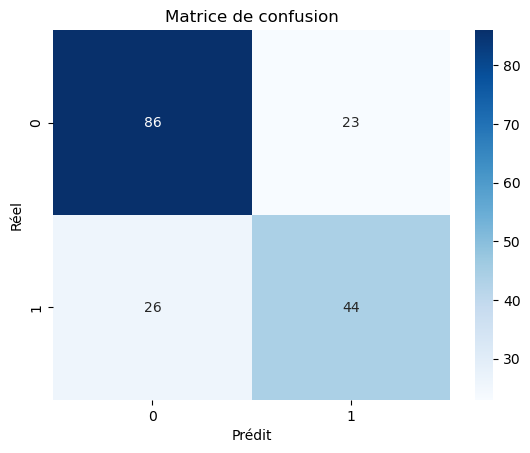

ROC AUC : 0.7750


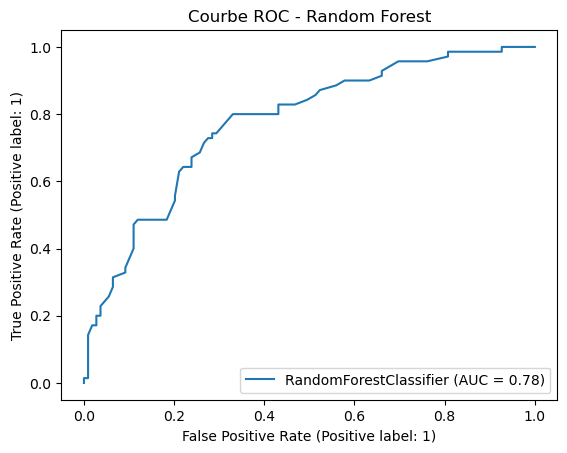

In [15]:
# Modèle Random Forest avec pondération automatique :Avec class_weight='balanced' pour compenser le déséquilibre entre les classes.
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Prédiction
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Rapport de classification
print("--- Random Forest (class_weight='balanced') ---")
print("Classification Report :")
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# ROC AUC
roc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC : {roc:.4f}")

# Courbe ROC
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Courbe ROC - Random Forest")
plt.show()

Le modèle Random Forest a correctement identifié la majorité des cas non graves (classe 0) avec un f1-score de 78 %.

Il détecte plus efficacement les cas graves (classe 1) que les modèles précédents, avec un rappel de 63 % et un f1-score de 64 %, ce qui marque un réel progrès.

Le score global est satisfaisant (accuracy = 73 %, macro f1 = 71 %), ce qui démontre une meilleure capacité du modèle à traiter un jeu de données déséquilibré.

Ce modèle constitue une base solide pour l’optimisation et l’analyse plus poussée des variables explicatives.

## XGBoost avec scale_pos_weight, un paramètre conçu pour gérer les classes déséquilibrées.

In [16]:
from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
print("scale_pos_weight =", scale_pos_weight)

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Prédiction
y_pred_xgb = xgb_model.predict(X_test)

# Évaluation
print("--- XGBoost ---")
print("Classification Report :")
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_xgb))

# Prédire les probabilités pour calculer AUC
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("\nROC AUC :", roc_auc_score(y_test, y_pred_proba_xgb))

scale_pos_weight = 1.5683453237410072
--- XGBoost ---
Classification Report :
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       109
           1       0.62      0.57      0.59        70

    accuracy                           0.69       179
   macro avg       0.68      0.67      0.67       179
weighted avg       0.69      0.69      0.69       179


Confusion Matrix :
[[84 25]
 [30 40]]

ROC AUC : 0.763826998689384


C:\Users\fatis\anaconda3\envs\accidents\lib\site-packages\xgboost\training.py:183: UserWarning: [17:20:03] WARNING: D:\bld\xgboost-split_1748292851775\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy : 69 % → légèrement plus faible qu’avec Random Forest (73 %), mais ce n’est pas le meilleur indicateur ici, car les classes sont déséquilibrées.

Le modèle XGBoost montre de bonnes performances globales avec une accuracy de 69 % et un f1-score global de 69 % (pondéré).

Il reconnaît efficacement la classe majoritaire (0) avec un f1-score de 75 %.

Pour la classe minoritaire (1), le rappel atteint 57 % et le f1-score grimpe à 59 %, ce qui montre une capacité raisonnable à détecter les cas graves.

Le ROC AUC de 76 % confirme une bonne séparation entre les deux classes.

Ce modèle offre un équilibre intéressant entre performance et robustesse, et mérite d’être conservé dans les modèles de référence..

## Test avec SMOTE (Synthetic Minority Over-sampling Technique)
Objectif : Rééquilibrer les classes en générant des exemples synthétiques de la classe minoritaire.

In [17]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Initialiser SMOTE
smote = SMOTE(random_state=42)

# Appliquer SMOTE uniquement sur les données d'entraînement
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Vérification du rééquilibrage
print("Avant SMOTE :", Counter(y_train))
print("Après SMOTE :", Counter(y_train_smote))

Avant SMOTE : Counter({0: 436, 1: 278})
Après SMOTE : Counter({0: 436, 1: 436})


## Entraîner un modèle sur les données SMOTE : Randomforestclassifier

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Entraînement
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

# Prédiction
y_pred_rf_smote = rf_smote.predict(X_test)
y_pred_proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

# Évaluation
print("--- Random Forest avec SMOTE ---")
print("Classification Report :")
print(classification_report(y_test, y_pred_rf_smote))
print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_rf_smote))
print("\nROC AUC :", roc_auc_score(y_test, y_pred_proba_rf_smote))

--- Random Forest avec SMOTE ---
Classification Report :
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       109
           1       0.68      0.63      0.65        70

    accuracy                           0.74       179
   macro avg       0.72      0.72      0.72       179
weighted avg       0.73      0.74      0.74       179


Confusion Matrix :
[[88 21]
 [26 44]]

ROC AUC : 0.7807994757536041


In [ ]:
XGBoost + SMOTE

In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Entraînement du modèle
xgb_smote = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=1,  # tu peux ajuster si besoin
    random_state=42
)
xgb_smote.fit(X_train_smote, y_train_smote)

# 2. Prédictions sur le jeu de test
y_pred_xgb_smote = xgb_smote.predict(X_test)
y_pred_proba_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

# 3. Évaluation du modèle
print("--- XGBoost avec SMOTE ---")
print("Classification Report :")
print(classification_report(y_test, y_pred_xgb_smote))

print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_xgb_smote))

print("\nROC AUC :", roc_auc_score(y_test, y_pred_proba_xgb_smote))

--- XGBoost avec SMOTE ---
Classification Report :
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       109
           1       0.66      0.64      0.65        70

    accuracy                           0.73       179
   macro avg       0.72      0.72      0.72       179
weighted avg       0.73      0.73      0.73       179


Confusion Matrix :
[[86 23]
 [25 45]]

ROC AUC : 0.778964613368283


C:\Users\fatis\anaconda3\envs\accidents\lib\site-packages\xgboost\training.py:183: UserWarning: [17:31:28] WARNING: D:\bld\xgboost-split_1748292851775\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Le modèle XGBoost entraîné sur des données rééquilibrées avec SMOTE montre des performances intéressantes :
F1-score global : 73 %, identique au modèle Random Forest SMOTE.
Classe majoritaire (non grave) :

Précision : 77 %, Rappel : 79 % → Bonne détection des cas non graves.

Classe minoritaire (grave) :

Rappel de 64 % → Meilleure détection des cas graves par rapport à la version sans SMOTE.

F1-score de 65 % → Très bon équilibre entre précision et rappel pour une classe difficile.

Score AUC : 0.779, ce qui indique une bonne capacité de séparation des classes.

Conclusion : L’ajout de SMOTE a clairement amélioré l’équilibre du modèle, notamment sur la classe minoritaire. Le XGBoost avec SMOTE donne des performances comparables au Random Forest SMOTE, avec une légère meilleure capacité à détecter les cas graves (rappel de 64 % contre 63 %).


